# Ventilation Index (Tang & Emanuel 2012) Demo

This notebook computes the Tang & Emanuel (2012) ventilation index step-by-step using:

- TE12 Eq. (1):  $\Lambda = (u_{\mathrm{shear}} / u_{PI})\,\chi_m$
- TE12 Eq. (2):  $\chi_m = (s_m^* - s_m) / (s_{SST}^* - s_b)$

We use the same example thermodynamic profile used in the `tcpyPI.pi` docstring.

Notes
-----
- The example profile does **not** include winds. We use a simple *synthetic* wind profile (cartoon example) chosen to yield moderate 850–200 hPa shear (~8 m/s).
- We approximate 2m boundary-layer conditions using the lowest model level from the profile (you would use true 2m fields in practice).
- The goal here is transparency: show how each TE12 term is computed and how each factor influences $\Lambda$.


In [1]:
import sys
from pathlib import Path

# Ensure we import the local repo version (src-layout) rather than a pip-installed tcpypi.
# When running from `notebooks/`, the package lives at `../src/tcpyPI`.
repo_root = Path.cwd().parent
src_path = repo_root / "src"
sys.path.insert(0, str(src_path))

import importlib

import numpy as np
import matplotlib.pyplot as plt

import tcpyPI
importlib.reload(tcpyPI)
print("Using tcpyPI from:", tcpyPI.__file__)
import tcpyPI.utilities as util

Using tcpyPI from: /home/dgilford/tcpyPI/src/tcpyPI/__init__.py


## 1) Define the example profile (same as `tcpyPI.pi` docstring)

- `P` in hPa
- `TC` in °C
- `R` in g/kg (mixing ratio)


In [2]:
SSTC = 30.0
MSL = 1010.0
level_data = np.array(
    [
        [1000, 28, 18],
        [975, 25, 18],
        [950, 24, 16],
        [925, 23, 13],
        [900, 22, 12],
        [875, 20, 11],
        [850, 19, 10],
        [825, 18, 10],
        [800, 16, 9],
        [775, 15, 8],
        [750, 13, 7],
        [700, 11, 4],
        [650, 8, 3],
        [600, 5, 1.7],
        [550, 2, 1.2],
        [500, -2, 1.7],
        [450, -6, 0.7],
        [400, -11, 0.2],
        [350, -18, 0.15],
        [300, -27, 0.10],
        [250, -37, 0.11],
        [225, -43, 0.08],
        [200, -49, 0.05],
        [175, -57, 0.03],
        [150, -65, 0.014],
        [125, -73, 0.005],
        [100, -79, 0.003],
        [70, -73, 0.002],
        [50, -64, 0.002],
    ]
)

P = level_data[:, 0]
TC = level_data[:, 1]
R = level_data[:, 2]

print("Profile levels:", len(P))
print("SSTC:", SSTC, "C")

Profile levels: 29
SSTC: 30.0 C


## 2) Compute PI (`u_PI`) with tcpyPI

We use the default `outflow_source="cape_star"` and `CKCD=0.9`.

In [3]:
VMAX, PMIN, IFL, T0, OTL = tcpyPI.pi(SSTC, MSL, P, TC, R, CKCD=0.9)
print("IFL:", IFL)
print("u_PI (VMAX):", VMAX, "m/s")
print("T0:", T0, "K")
print("OTL:", OTL, "hPa")
print("PMIN:", PMIN, "hPa")

IFL: 1
u_PI (VMAX): 82.48454558813637 m/s
T0: 197.16661355426555 K
OTL: 84.91693222867204 hPa
PMIN: 900.2039194560052 hPa


## 3) Set a representative deep-layer shear magnitude

Tang & Emanuel define `u_shear = |u850 - u200|` (bulk 850–200 hPa shear magnitude).
For this demo, we define a simple synthetic wind profile representative of *moderate* 850–200 hPa shear (~8 m/s), then compute `u_shear` from it.

850 hPa wind (u,v): (np.float64(-4.0), np.float64(2.0)) m/s
200 hPa wind (u,v): (np.float64(3.746), np.float64(0.0)) m/s
u_shear (850–200): 8.000032249934996 m/s


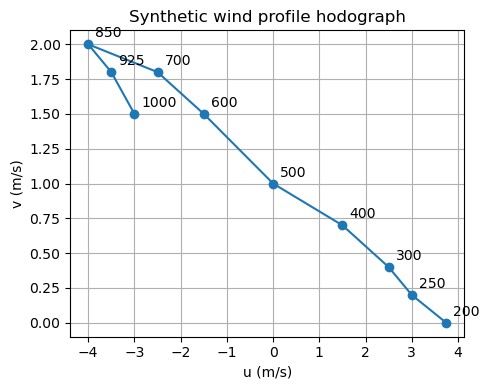

In [4]:
# Synthetic wind profile for 25N / central Gulf (cartoon example).
# Values are chosen to yield ~8 m/s 850–200 hPa bulk shear magnitude.
p_wind = np.array([1000, 925, 850, 700, 600, 500, 400, 300, 250, 200], dtype=float)

# u (eastward) and v (northward), m/s.
# Low-level easterlies with slight southerly component; upper-level westerlies.
u = np.array([-3.0, -3.5, -4.0, -2.5, -1.5,  0.0,  1.5,  2.5,  3.0,  3.746], dtype=float)
v = np.array([ 1.5,  1.8,  2.0,  1.8,  1.5,  1.0,  0.7,  0.4,  0.2,  0.0  ], dtype=float)

u850, v850 = u[p_wind == 850][0], v[p_wind == 850][0]
u200, v200 = u[p_wind == 200][0], v[p_wind == 200][0]
u_shear = float(np.hypot(u850 - u200, v850 - v200))
print("850 hPa wind (u,v):", (u850, v850), "m/s")
print("200 hPa wind (u,v):", (u200, v200), "m/s")
print("u_shear (850–200):", u_shear, "m/s")

plt.figure(figsize=(5, 4))
plt.plot(u, v, "o-")
for pi, ui, vi in zip(p_wind, u, v):
    plt.text(ui + 0.15, vi + 0.05, f"{int(pi)}")
plt.xlabel("u (m/s)")
plt.ylabel("v (m/s)")
plt.title("Synthetic wind profile hodograph")
plt.grid(True)
plt.tight_layout()
plt.show()

## 4) Compute the entropy deficit χm step-by-step

We use midlevel `p_mid = 600 hPa` as in TE12, and compute:

- `s_m`: environmental entropy at 600 hPa
- `s_m*`: saturation entropy at 600 hPa (using environmental temperature at 600 hPa)
- `s_SST*`: saturation entropy at SST at surface pressure
- `s_b`: boundary-layer entropy (here approximated using lowest-level profile as “2m”)


In [5]:
p_mid = 600.0
mid_i = int(np.where(P == p_mid)[0][0])

T_mid_C = float(TC[mid_i])
T_mid_K = T_mid_C + 273.15
R_mid_gg = float(R[mid_i]) * 0.001  # g/kg -> g/g

# sm
s_m = util.entropy_S(T_mid_K, R_mid_gg, p_mid)

# s*m: saturation at midlevel
es_mid = util.es_cc(T_mid_C)
R_mid_sat = util.rv(es_mid, p_mid)
s_m_star = util.entropy_S(T_mid_K, R_mid_sat, p_mid)

# s*SST: saturation at SST and surface pressure
SST_K = SSTC + 273.15
es_sst = util.es_cc(SSTC)
R_sst_sat = util.rv(es_sst, float(MSL))
s_sst_star = util.entropy_S(SST_K, R_sst_sat, float(MSL))

# sb: boundary layer (2m proxy)
T2m_C = float(TC[0])
T2m_K = T2m_C + 273.15
R2m_gg = float(R[0]) * 0.001
s_b = util.entropy_S(T2m_K, R2m_gg, float(MSL))

chi_m = (s_m_star - s_m) / (s_sst_star - s_b)

print("sm      :", s_m)
print("sm_star :", s_m_star)
print("sSST_star:", s_sst_star)
print("sb      :", s_b)
print("chi_m   :", chi_m)

sm      : 3865.349132328631
sm_star : 4039.7403311081575
sSST_star: 4386.809269655979
sb      : 4170.322834367552
chi_m   : 0.8055525444223943


### (Optional) Compare against the helper in tcpyPI

This uses the same defaults described in the function docstring.

We also compare two entropy-method choices for TE12 Eq. (2):
- `emanuel94`: uses `tcpyPI.utilities.entropy_S` (what tcpyPI uses elsewhere)
- `bryan2008`: the pseudo-adiabatic entropy described in TE12 Eq. (3)

These methods can yield different χm and thus different Λ.

In [6]:
chi_m_api_emanuel = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="emanuel94",
)
chi_m_api_bryan = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="bryan2008",
)

print("chi_m (manual, Emanuel-style):", chi_m)
print("chi_m (API, emmanuel94)      :", chi_m_api_emanuel)
print("chi_m (API, bryan2008)       :", chi_m_api_bryan)
print("Δ(bryan - emanuel)           :", float(chi_m_api_bryan - chi_m_api_emanuel))

chi_m (manual, Emanuel-style): 0.8055525444223943
chi_m (API, emmanuel94)      : 0.8055525444223943
chi_m (API, bryan2008)       : 0.8254318794376412
Δ(bryan - emanuel)           : 0.019879335015246857


In [7]:
# Compare s_m* definitions (storm-core saturation entropy at midlevels)
# - env_T_at_pmid: s* at p_mid using environmental T(p_mid) with RH=100%
# - moist_adiabat_from_sst: lift a saturated parcel from SST at psfc to p_mid (moist adiabat)

chi_envT_emanuel = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="emanuel94",
    s_m_star_source="env_T_at_pmid",
)
chi_moist_emanuel = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="emanuel94",
    s_m_star_source="moist_adiabat_from_sst",
)

chi_envT_bryan = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="bryan2008",
    s_m_star_source="env_T_at_pmid",
)
chi_moist_bryan = tcpyPI.entropy_deficit_te12_from_profile(
    P,
    TC,
    R,
    T_units="C",
    q_units="g/kg",
    SST=SSTC,
    SST_units="C",
    psfc_hpa=MSL,
    T2m=T2m_C,
    q2m=float(R[0]),
    entropy_method="bryan2008",
    s_m_star_source="moist_adiabat_from_sst",
)

print('chi_m (emanuel94, env_T_at_pmid)        :', float(chi_envT_emanuel))
print('chi_m (emanuel94, moist_adiabat_from_sst):', float(chi_moist_emanuel))
print('chi_m (bryan2008, env_T_at_pmid)        :', float(chi_envT_bryan))
print('chi_m (bryan2008, moist_adiabat_from_sst):', float(chi_moist_bryan))

VI_envT_emanuel = tcpyPI.ventilation_index(u_shear, VMAX, chi_envT_emanuel)
VI_moist_emanuel = tcpyPI.ventilation_index(u_shear, VMAX, chi_moist_emanuel)
VI_envT_bryan = tcpyPI.ventilation_index(u_shear, VMAX, chi_envT_bryan)
VI_moist_bryan = tcpyPI.ventilation_index(u_shear, VMAX, chi_moist_bryan)

print('VI (emanuel94, env_T_at_pmid)        :', float(VI_envT_emanuel))
print('VI (emanuel94, moist_adiabat_from_sst):', float(VI_moist_emanuel))
print('VI (bryan2008, env_T_at_pmid)        :', float(VI_envT_bryan))
print('VI (bryan2008, moist_adiabat_from_sst):', float(VI_moist_bryan))


chi_m (emanuel94, env_T_at_pmid)        : 0.8055525444223943
chi_m (emanuel94, moist_adiabat_from_sst): 2.4087427746124694
chi_m (bryan2008, env_T_at_pmid)        : 0.8254318794376412
chi_m (bryan2008, moist_adiabat_from_sst): 1.8863433304081907
VI (emanuel94, env_T_at_pmid)        : 0.07812913665760976
VI (emanuel94, moist_adiabat_from_sst): 0.23361976163288992
VI (bryan2008, env_T_at_pmid)        : 0.08005719869753825
VI (bryan2008, moist_adiabat_from_sst): 0.18295315043701715


### Why can this change be large?

For the TE12 entropy deficit,

$$\chi_m = \frac{s_m^* - s_m}{s_{SST}^* - s_b}$$

Switching `s_m_star_source` changes only the numerator term $s_m^*$:
- `env_T_at_pmid` uses $T(p_{mid})$ and sets RH=100%.
- `moist_adiabat_from_sst` lifts a *saturated* parcel from SST to $p_{mid}$. In our implementation this is treated as **constant saturation entropy**, so $s_m^*$ becomes approximately $s_{SST}^*$.

If the boundary layer is fairly humid, $(s_{SST}^* - s_b)$ can be modest, so changing $s_m^*$ can shift $\chi_m$ noticeably.

In [8]:
# Inspect the TE12 entropy terms (Emanuel-style entropy) to sanity-check magnitudes.
# This helps confirm the change is coming from physics/definitions, not a unit mistake.

import numpy as np
import tcpyPI.utilities as util

p_mid = 600.0
mid_i = int(np.where(P == p_mid)[0][0])

SST_K = SSTC + 273.15
T2m_K = T2m_C + 273.15
T_mid_K = float(TC[mid_i]) + 273.15
R2m = float(R[0]) * 0.001       # g/kg -> g/g
R_mid = float(R[mid_i]) * 0.001 # g/kg -> g/g

# s_SST*: saturation entropy at SST (surface pressure)
es_sst = util.es_cc(SSTC)
R_sst_sat = util.rv(es_sst, float(MSL))
s_sst_star = util.entropy_S(SST_K, R_sst_sat, float(MSL))

# s_b: boundary-layer entropy at 2m
s_b = util.entropy_S(T2m_K, R2m, float(MSL))

# s_m: environmental entropy at p_mid
s_m = util.entropy_S(T_mid_K, R_mid, p_mid)

# s_m* (env_T_at_pmid): saturation entropy at p_mid using environmental T(p_mid)
es_mid = util.es_cc(float(TC[mid_i]))
R_mid_sat = util.rv(es_mid, p_mid)
s_m_star_envT = util.entropy_S(T_mid_K, R_mid_sat, p_mid)

# s_m* (moist_adiabat_from_sst): in this implementation, this is ~ s_SST*
# (computed by lifting along constant saturation entropy)
chi_envT = (s_m_star_envT - s_m) / (s_sst_star - s_b)
chi_moist = (s_sst_star - s_m) / (s_sst_star - s_b)

print('s_SST*   :', float(s_sst_star))
print('s_b      :', float(s_b))
print('s_m      :', float(s_m))
print('s_m* envT:', float(s_m_star_envT))
print('denom (s_SST* - s_b):', float(s_sst_star - s_b))
print('chi_m (env_T_at_pmid)        :', float(chi_envT))
print('chi_m (moist_adiabat_from_sst):', float(chi_moist))


s_SST*   : 4386.809269655979
s_b      : 4170.322834367552
s_m      : 3865.349132328631
s_m* envT: 4039.7403311081575
denom (s_SST* - s_b): 216.48643528842695
chi_m (env_T_at_pmid)        : 0.8055525444223943
chi_m (moist_adiabat_from_sst): 2.4087427770363594


## 5) Compute the ventilation index Λ

TE12 Eq. (1):  $\Lambda = (u_{\mathrm{shear}} / u_{PI})\,\chi_m$

In [9]:
VI = tcpyPI.ventilation_index(u_shear, VMAX, chi_m, formulation="te12")
print("VI (Lambda):", VI)

VI (Lambda): 0.07812913665760976


## 6) Visualize the drivers of $\Lambda$

Because TE12 Eq. (1) is multiplicative, it is often clearer to look in log space:

$$\ln\Lambda = \ln u_{\mathrm{shear}} - \ln u_{PI} + \ln \chi_m$$

This makes the *relative* influence of each factor easy to interpret (elasticities):
- a 1% increase in $u_{\mathrm{shear}}$ increases $\Lambda$ by ~1%
- a 1% increase in $u_{PI}$ decreases $\Lambda$ by ~1%
- a 1% increase in $\chi_m$ increases $\Lambda$ by ~1%

We plot both the log-space contributions and a simple one-at-a-time perturbation test (±20%) to show sensitivities.


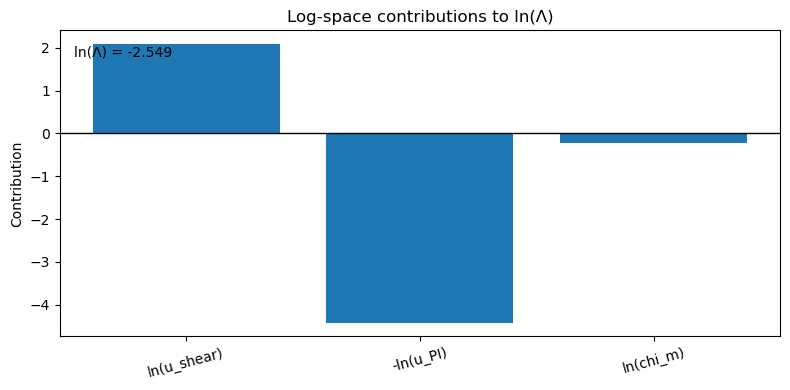

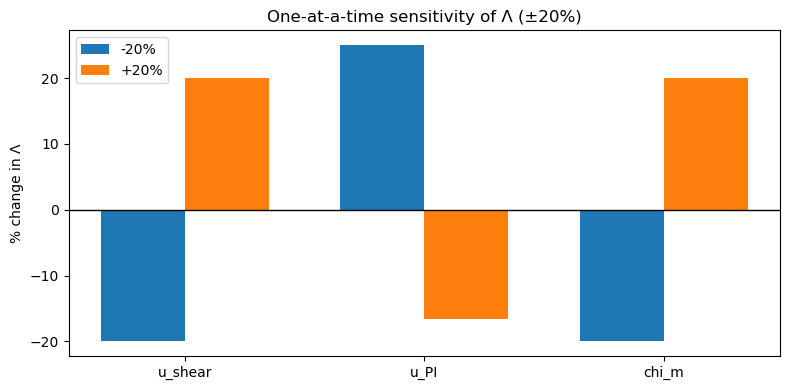

In [10]:
# Log-space decomposition (additive contributions)
ln_shear = float(np.log(u_shear))
ln_chi = float(np.log(chi_m))
ln_pi = float(np.log(VMAX))
ln_lambda = float(np.log(VI))

terms = {
    'ln(u_shear)': ln_shear,
    '-ln(u_PI)': -ln_pi,
    'ln(chi_m)': ln_chi,
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='k', linewidth=1)
ax.bar(list(terms.keys()), list(terms.values()))
ax.set_title('Log-space contributions to ln(Λ)')
ax.set_ylabel('Contribution')
ax.text(0.02, 0.95, f'ln(Λ) = {ln_lambda:.3f}', transform=ax.transAxes, va='top')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# One-at-a-time sensitivity: perturb each factor by ±20%
def lambda_from(u_shear_val, u_pi_val, chi_val):
    return (u_shear_val / u_pi_val) * chi_val

base = float(VI)
perturb = 0.20
scenarios = []
for name, (u_shear_val, u_pi_val, chi_val) in [
    ('u_shear', (u_shear, VMAX, chi_m)),
    ('u_PI', (u_shear, VMAX, chi_m)),
    ('chi_m', (u_shear, VMAX, chi_m)),
]:
    if name == 'u_shear':
        low = lambda_from(u_shear * (1 - perturb), VMAX, chi_m)
        high = lambda_from(u_shear * (1 + perturb), VMAX, chi_m)
    elif name == 'u_PI':
        low = lambda_from(u_shear, VMAX * (1 - perturb), chi_m)
        high = lambda_from(u_shear, VMAX * (1 + perturb), chi_m)
    else:  # chi_m
        low = lambda_from(u_shear, VMAX, chi_m * (1 - perturb))
        high = lambda_from(u_shear, VMAX, chi_m * (1 + perturb))
    scenarios.append((name, (low / base - 1) * 100, (high / base - 1) * 100))

labels = [s[0] for s in scenarios]
low_changes = [s[1] for s in scenarios]
high_changes = [s[2] for s in scenarios]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='k', linewidth=1)
ax.bar(x - width/2, low_changes, width, label='-20%')
ax.bar(x + width/2, high_changes, width, label='+20%')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% change in Λ')
ax.set_title('One-at-a-time sensitivity of Λ (±20%)')
ax.legend()
plt.tight_layout()
plt.show()
